# Training and evaluation with `tv.models` and `tv.evaluation`

Three backends sit behind one `Model` interface:

| name | library | task |
|---|---|---|
| `yolo` | Ultralytics YOLO | player, goalkeeper, referee and ball boxes |
| `rfdetr` | RF-DETR | the same boxes, transformer detector |
| `yolo_pose` | Ultralytics YOLO-pose | the 32 pitch landmarks |

All three train with the same `train` call and are scored by the same
evaluation code, so their numbers compare directly.

The training runs here are **short demos**: a few epochs on a subset, enough
to show the interface in a few minutes. The checkpoints in `models/` were
trained on the full datasets for far longer (200 epochs for the YOLO models,
about 30 for RF-DETR), and they are the ones the other notebooks use.

Part of the [TactiFoot Vision notebooks](README.md).

In [1]:
import os
from pathlib import Path

import pandas as pd

import tactifoot_vision as tv

# The repository root, found by walking up from the working directory and kept
# relative, so printed paths do not depend on where the repository lives.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file()
)
ROOT = Path(os.path.relpath(_root))
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebooks" / "03_training_and_evaluation"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}

detection = tv.load_dataset(DATA / "datasets" / "football_yolo")
pitch_data = tv.load_dataset(DATA / "keypoints")
train_set = detection.subset({"train": 300, "valid": 60}, seed=0)  # demo-sized
print(train_set)

Dataset(name='football_yolo', task=detect, classes=['ball', 'goalkeeper', 'player', 'referee'], train=300, valid=60)


## Backends and settings

Models are looked up by name in a registry. `available_models` lists them, and
`tv.load_model(name, weights, ...)` creates one.

In [2]:
tv.models.available_models()

['rfdetr', 'yolo', 'yolo_pose']

`TrainConfig` holds the settings every backend understands, with their
defaults. Anything else passed to it is a backend option and goes to the
backend unchanged (`mosaic` for Ultralytics, `grad_accum_steps` for RF-DETR).

In [3]:
fields = tv.TrainConfig.model_fields
pd.DataFrame(
    {
        "default": {name: field.default for name, field in fields.items()},
        "description": {
            name: field.description or "" for name, field in fields.items()
        },
    }
)

,default,description
epochs,10,
batch_size,8,
imgsz,640,
lr,None,None keeps the backend default
device,None,
workers,4,
patience,None,Early-stopping patience in epochs
seed,0,
output_dir,runs,
name,None,Run folder name; defaults to the model name


In [4]:
print(tv.TrainConfig(epochs=50, mosaic=0.0))
print("backend options:", tv.TrainConfig(epochs=50, mosaic=0.0).backend_options)

epochs=50 batch_size=8 imgsz=640 lr=None device=None workers=4 patience=None seed=0 output_dir=PosixPath('runs') name=None exist_ok=False mosaic=0.0
backend options: {'mosaic': 0.0}


One config serves all three demo runs below: few epochs, everything written
under this notebook's output folder. `exist_ok=True` reuses the run folders
when the notebook runs again instead of numbering new ones.

In [5]:
config = tv.TrainConfig(
    epochs=20, batch_size=16, output_dir=OUT / "runs", exist_ok=True
)

## Training: one call for every backend

`tv.train(name, dataset, config, weights=..., **overrides)` exports the dataset
in the format the backend needs (YOLO folder or COCO folder) into the run
folder, trains, and returns a `TrainResult`. Keyword overrides replace single
config fields. The trainers print a lot, so `%%capture` keeps their logs out of
the notebook (`yolo_log.show()` prints them).

The detectors train on the 300-image subset, a few of which are shown first.

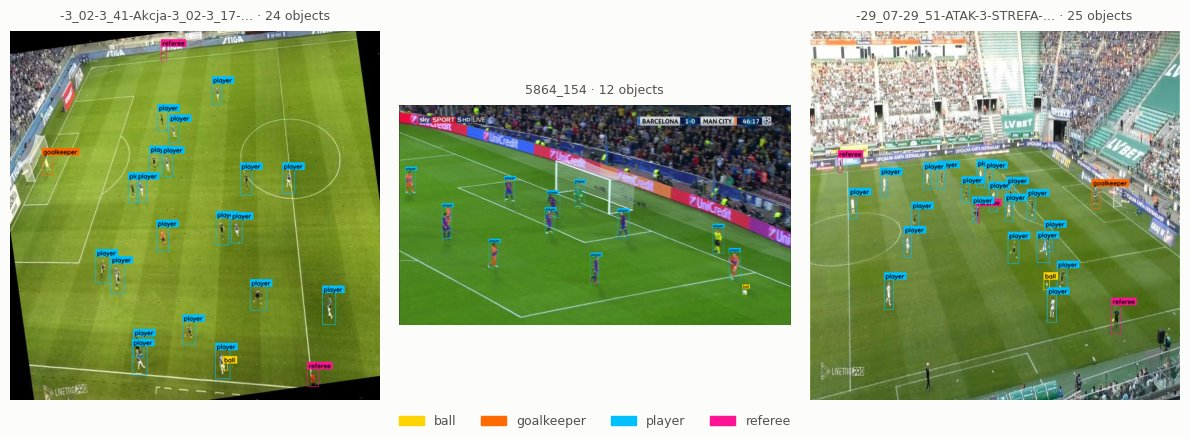

In [6]:
tv.viz.show_samples(train_set, "train", n=3)

In [7]:
%%capture yolo_log
yolo_run = tv.train("yolo", train_set, config, weights="yolo11n.pt", name="yolo11n")

A `TrainResult` holds the best checkpoint, the run folder, the per-epoch
history and the validation metrics of the best checkpoint. Metric keys are the
same for every backend.

In [8]:
print("weights:", os.path.relpath(yolo_run.weights))
print("metrics:", {k: round(v, 3) for k, v in yolo_run.metrics.items()})
yolo_run.history.head(3)

weights: ../outputs/notebooks/03_training_and_evaluation/runs/yolo11n/weights/best.pt
metrics: {'precision': 0.81, 'recall': 0.504, 'map50': 0.557, 'map50_95': 0.314}


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,2.13794,2.25340,3.72639,1.20488,0.00496,0.07199,0.01281,0.00251,2.31096,4.03213,1.12365,0.000225,0.000225,0.000225
1,2,3.33195,1.94426,2.34764,1.07037,0.00702,0.08541,0.03953,0.00994,1.88748,3.74824,0.98907,0.000440,0.000440,0.000440
2,3,4.53764,1.89123,1.58132,1.06213,0.01414,0.14200,0.07030,0.02289,2.30751,3.33296,1.16330,0.000631,0.000631,0.000631


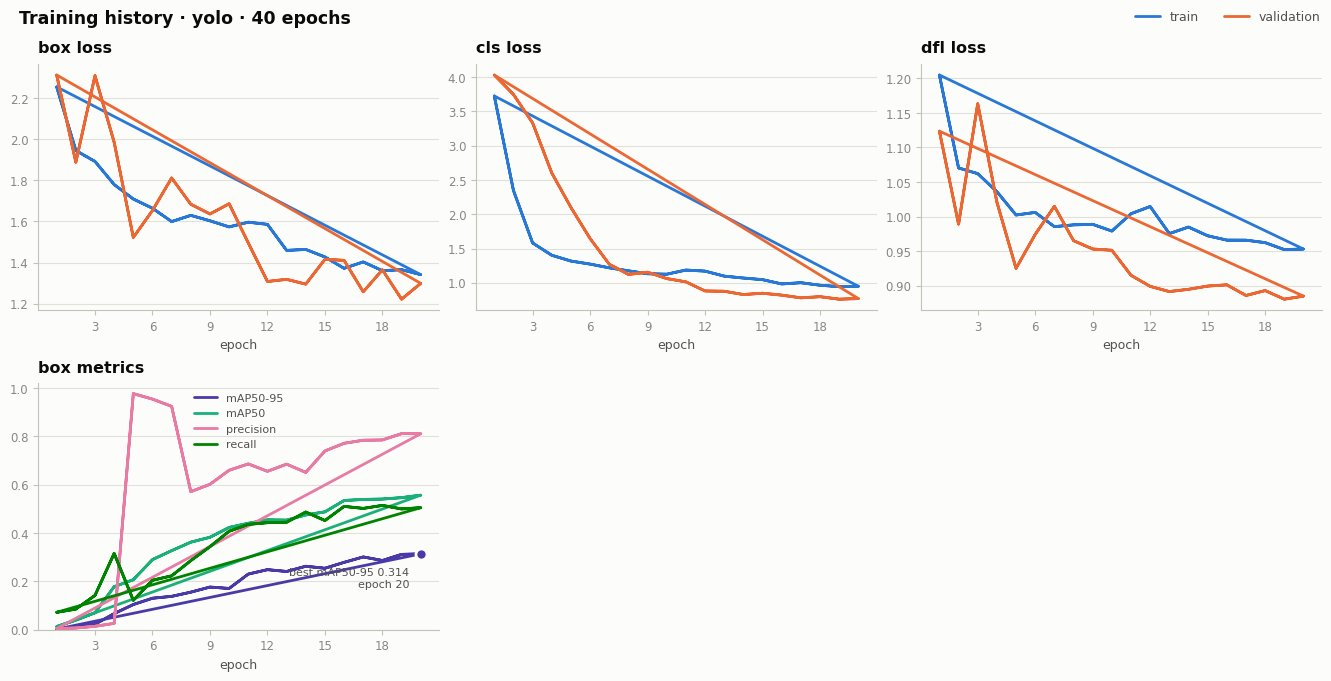

In [9]:
tv.viz.plot_training(yolo_run)

RF-DETR trains through the same interface. Here the model is created first and
trained with `Model.train`, the method form of the same call; afterwards the
object holds the trained weights. `weights=None` starts from the COCO-pretrained
checkpoint. `grad_accum_steps` is an RF-DETR option.

In [10]:
%%capture rfdetr_log
rfdetr = tv.load_model("rfdetr", size="base")
rfdetr_run = rfdetr.train(
    train_set, config, epochs=3, batch_size=4, grad_accum_steps=4, name="rfdetr"
)

metrics: {'map50_95': 0.236, 'map50': 0.508, 'map75': 0.183}


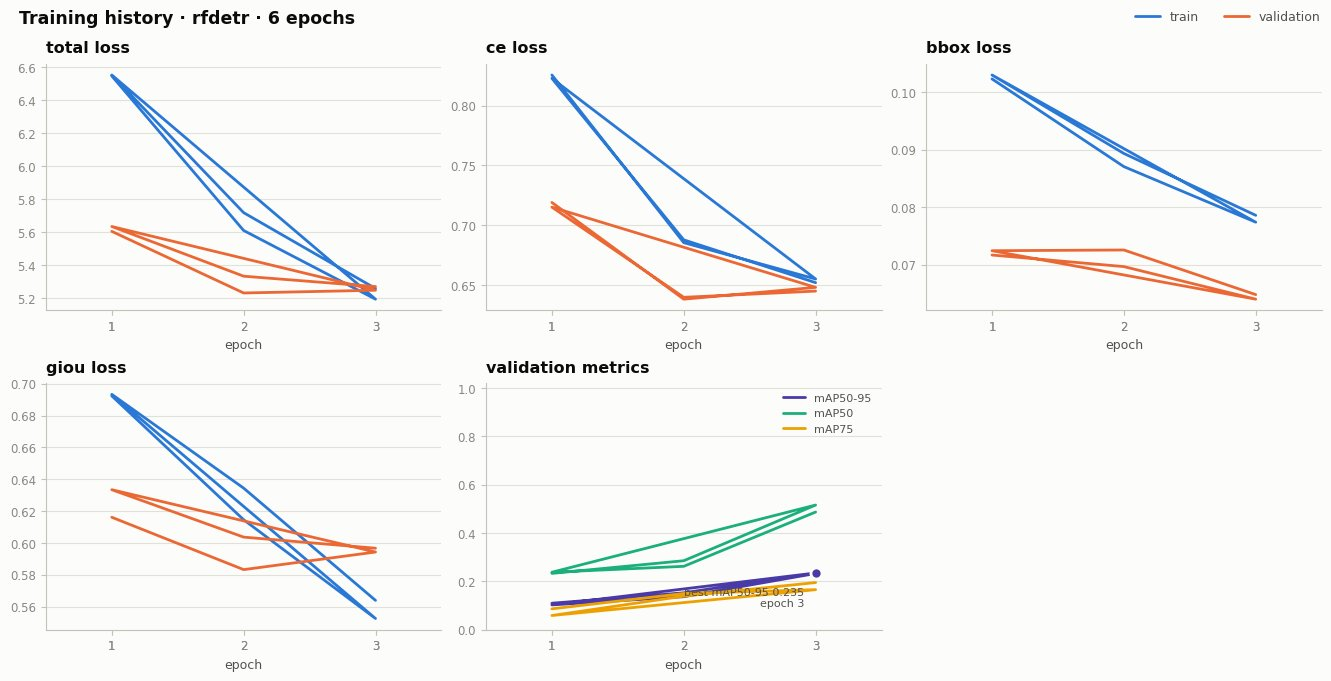

In [11]:
print("metrics:", {k: round(v, 3) for k, v in rfdetr_run.metrics.items()})
tv.viz.plot_training(rfdetr_run)

RF-DETR ignores options it does not know, so a typo would go unnoticed. The
backend checks them and fails before training starts.

In [12]:
try:
    rfdetr.train(train_set, config, epoch=5)
except ValueError as error:
    print("ValueError:", error)

ValueError: Unknown RF-DETR training options: epoch


The pitch keypoint model is a pose model. It trains on the pose dataset with
the same call; the dataset's `flip_idx` goes into the exported `data.yaml`, so
Ultralytics' own flip augmentation renames landmarks correctly.

In [13]:
%%capture pose_log
pose_run = tv.train(
    "yolo_pose",
    pitch_data,
    config,
    weights="yolov8n-pose.pt",
    epochs=40,
    name="pitch_pose",
)

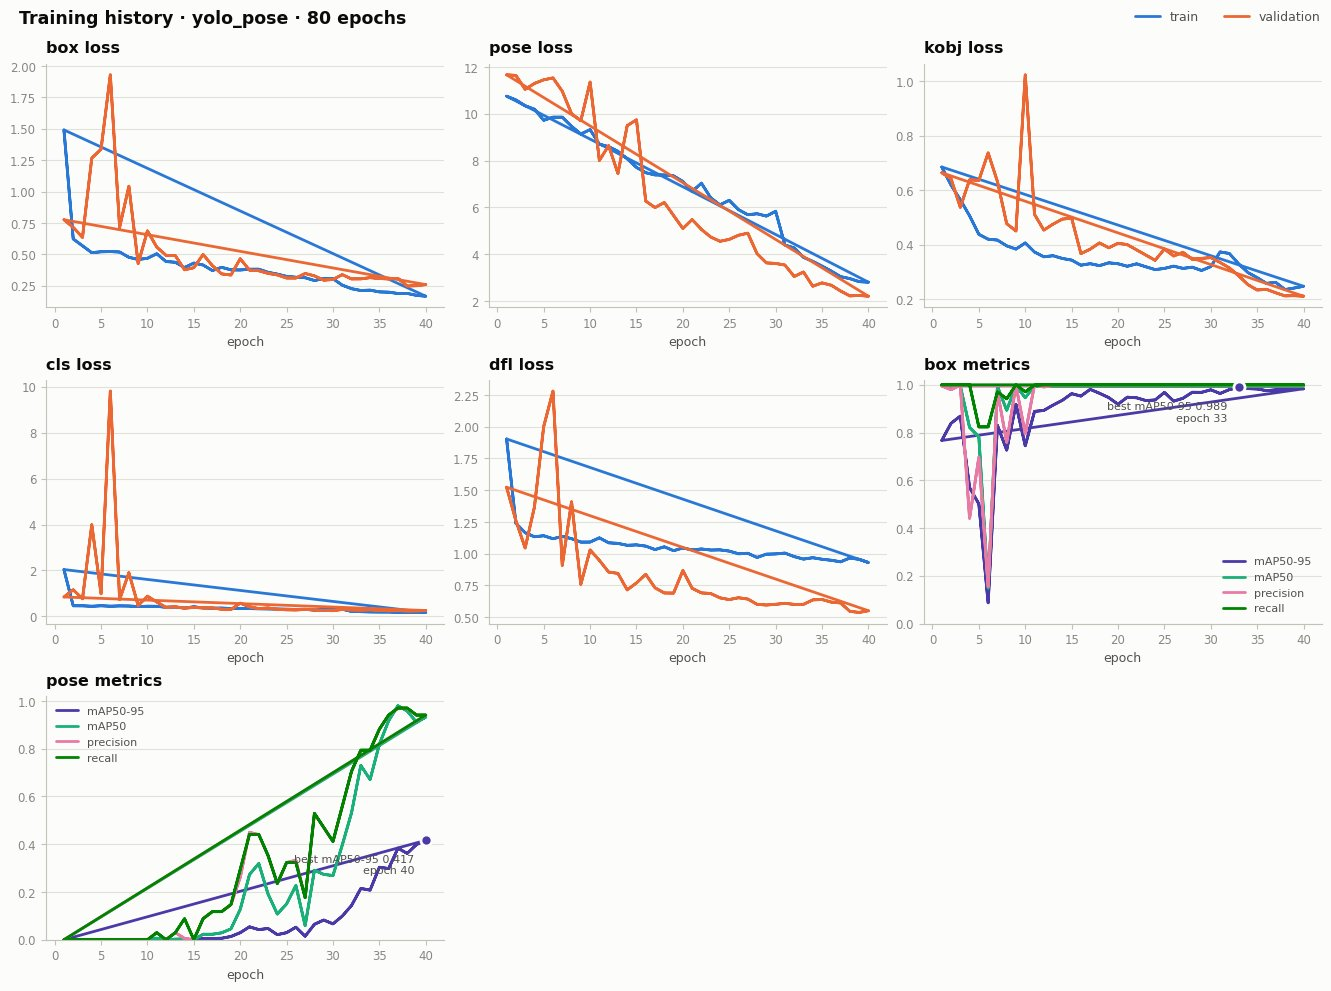

In [14]:
tv.viz.plot_training(pose_run)

## Evaluation

`tv.evaluate(model, dataset, split="valid")` (or `model.evaluate(dataset)`)
picks the metrics from the model's task. Detectors get COCO-style mAP computed
by one shared implementation, with classes matched by name, so YOLO and
RF-DETR are scored identically. `TrainResult.load()` rebuilds a trained model.

In [15]:
detectors = {
    "YOLO11n (demo run)": yolo_run.load(),
    "RF-DETR base (demo run)": rfdetr,
    "YOLO11m (models/)": tv.load_model("yolo", MODELS / "football_yolo11m.pt"),
    "RF-DETR base (models/)": tv.load_model(
        "rfdetr", MODELS / "football_rfdetr_base.pth"
    ),
}
detection_metrics = {
    name: tv.evaluate(model, detection) for name, model in detectors.items()
}
pd.DataFrame({name: m.as_dict() for name, m in detection_metrics.items()}).T.round(3)

Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


,map50_95,map50,map75
YOLO11n (demo run),0.281,0.494,0.294
RF-DETR base (demo run),0.235,0.522,0.153
YOLO11m (models/),0.452,0.782,0.465
RF-DETR base (models/),0.455,0.833,0.448


`DetectionMetrics` also has a per-class table. The ball, small and often
blurred, is the hardest class.

In [16]:
detection_metrics["RF-DETR base (models/)"].per_class.round(3)

,map50_95,map50,map75,instances
class_name,,,,
ball,0.252,0.644,0.131,197
goalkeeper,0.475,0.842,0.523,63
player,0.586,0.933,0.664,3414
referee,0.505,0.912,0.475,194


`plot_metrics` draws one model's per-class AP, or compares several side by side
when given a dict.

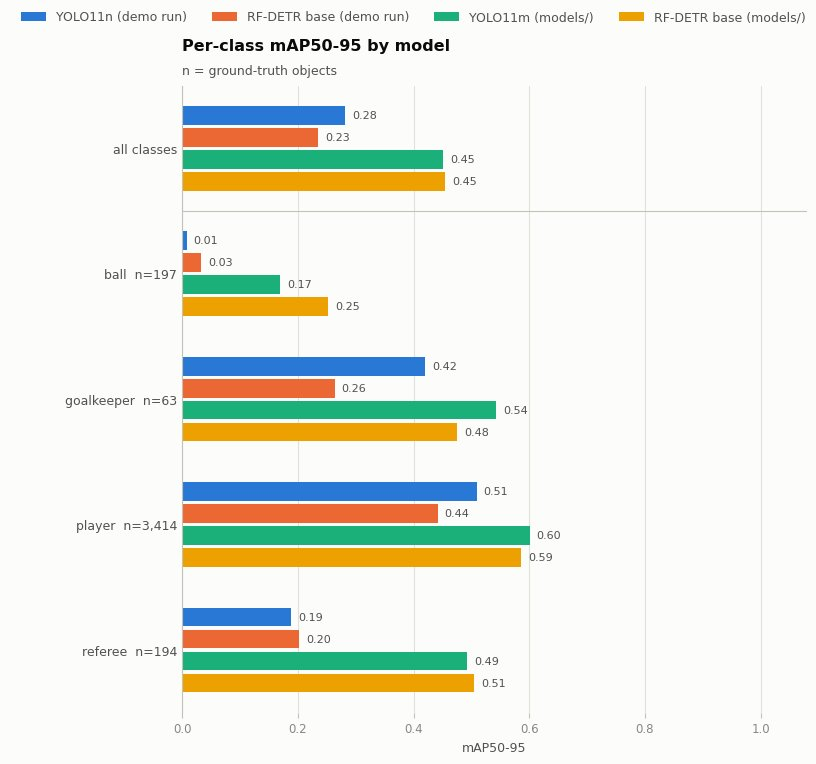

In [17]:
tv.viz.plot_metrics(detection_metrics)

Keypoint models get the mean pixel error of labelled landmarks and PCK, the
share of landmarks closer than a fraction of the image diagonal (5% by
default). Evaluation options pass through, here a stricter `pck_threshold`.

In [18]:
pitch_models = {
    "YOLOv8n-pose (demo run)": pose_run.load(),
    "YOLOv8n-pose (models/)": tv.load_model(
        "yolo_pose", MODELS / "pitch_yolov8n_pose.pt"
    ),
}
pitch_metrics = {
    name: model.evaluate(pitch_data, pck_threshold=0.02)
    for name, model in pitch_models.items()
}
pd.DataFrame({name: m.as_dict() for name, m in pitch_metrics.items()}).T.round(3)

,mean_error_px,pck,detection_rate
YOLOv8n-pose (demo run),21.807,0.555,1.0
YOLOv8n-pose (models/),8.442,0.926,1.0


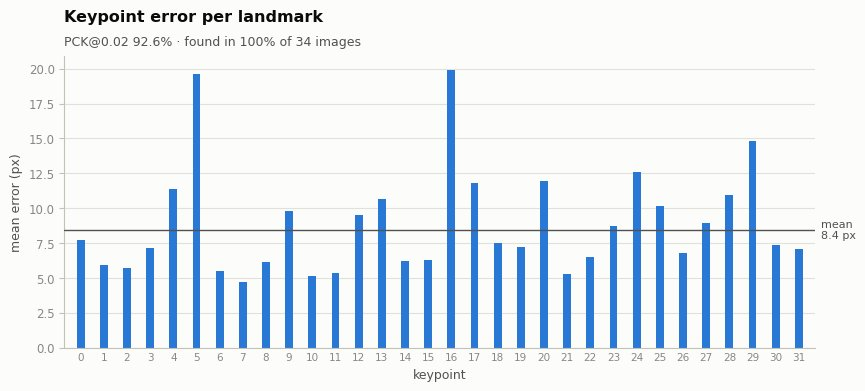

In [19]:
tv.viz.plot_metrics(pitch_metrics["YOLOv8n-pose (models/)"])